## **Aramco Analysis**

In [74]:
import yfinance as yf
import pandas as pd

In [75]:
aramco_data = yf.download('2222.SR', period="5y")

if isinstance(aramco_data.columns, pd.MultiIndex):
    aramco_data.columns = aramco_data.columns.get_level_values(0)

[*********************100%***********************]  1 of 1 completed


In [76]:
aramco_data['MA20'] = aramco_data['Close'].rolling(window=20).mean()

aramco_data['MA100'] = aramco_data['Close'].rolling(window=100).mean()

aramco_data['Daily_Return'] = aramco_data['Close'].pct_change() * 100

aramco_data.dropna(inplace=True)


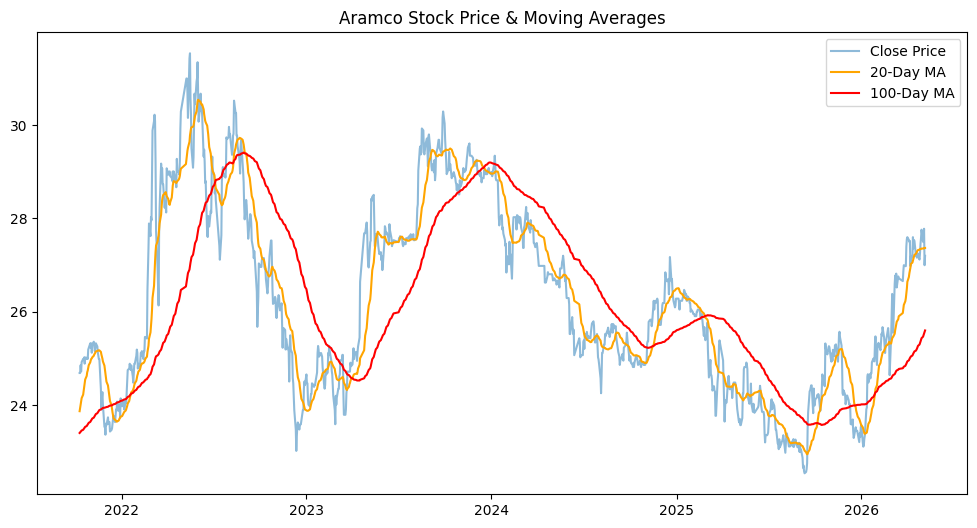

In [77]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,6))
plt.plot(aramco_data['Close'], label='Close Price', alpha=0.5)
plt.plot(aramco_data['MA20'], label='20-Day MA', color='orange')
plt.plot(aramco_data['MA100'], label='100-Day MA', color='red')

plt.title('Aramco Stock Price & Moving Averages')
plt.legend()
plt.show()

In [78]:
aramco_data.to_csv('Aramco_Full_Analysis.csv')
print('File Saved Successfully')

File Saved Successfully


## **ExxonMobil Analysis**

In [79]:
exxon_data = yf.download('XOM' , period='5y')

if isinstance(exxon_data.columns, pd.MultiIndex):
    exxon_data.columns = exxon_data.columns.get_level_values(0)

[*********************100%***********************]  1 of 1 completed


In [80]:
exxon_data['MA20'] = exxon_data['Close'].rolling(window=20).mean()

exxon_data['MA100'] = exxon_data['Close'].rolling(window=100).mean()

exxon_data['Daily_Return'] = exxon_data['Close'].pct_change() *100

exxon_data.dropna(inplace=True)

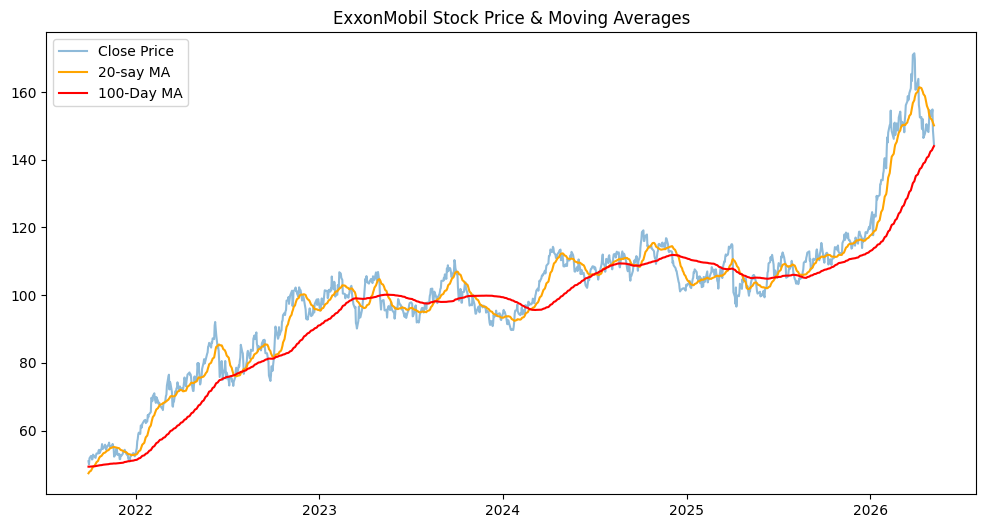

In [81]:
plt.figure(figsize=(12,6))
plt.plot(exxon_data['Close'] , label='Close Price' , alpha=0.5)
plt.plot(exxon_data['MA20'] , label='20-say MA' , color='orange')
plt.plot(exxon_data['MA100'] , label='100-Day MA' , color='red')
plt.title('ExxonMobil Stock Price & Moving Averages')
plt.legend()
plt.show()

In [82]:
exxon_data.to_csv('ExxonMobil_Full_Analysis.csv')
print('File Saved Successfully')

File Saved Successfully


## **Comparison (Aramco & ExxonMobil)**

In [83]:
comparison_df = pd.concat([aramco_data['Close'], exxon_data['Close']], axis=1)

comparison_df.columns = ['Aramco', 'Exxon']

comparison_df.dropna(inplace=True)


/var/folders/d0/95kqc37s02lft1nldlns8k4h0000gn/T/ipykernel_15634/1010087844.py:1: Pandas4Warning: Sorting by default when concatenating all DatetimeIndex is deprecated.  In the future, pandas will respect the default of `sort=False`. Specify `sort=True` or `sort=False` to silence this message. If you see this warnings when not directly calling concat, report a bug to pandas.
  comparison_df = pd.concat([aramco_data['Close'], exxon_data['Close']], axis=1)


In [84]:
correlation = comparison_df.corr()
print("Correlation Matrix:")
print(correlation)

Correlation Matrix:
          Aramco     Exxon
Aramco  1.000000 -0.138756
Exxon  -0.138756  1.000000


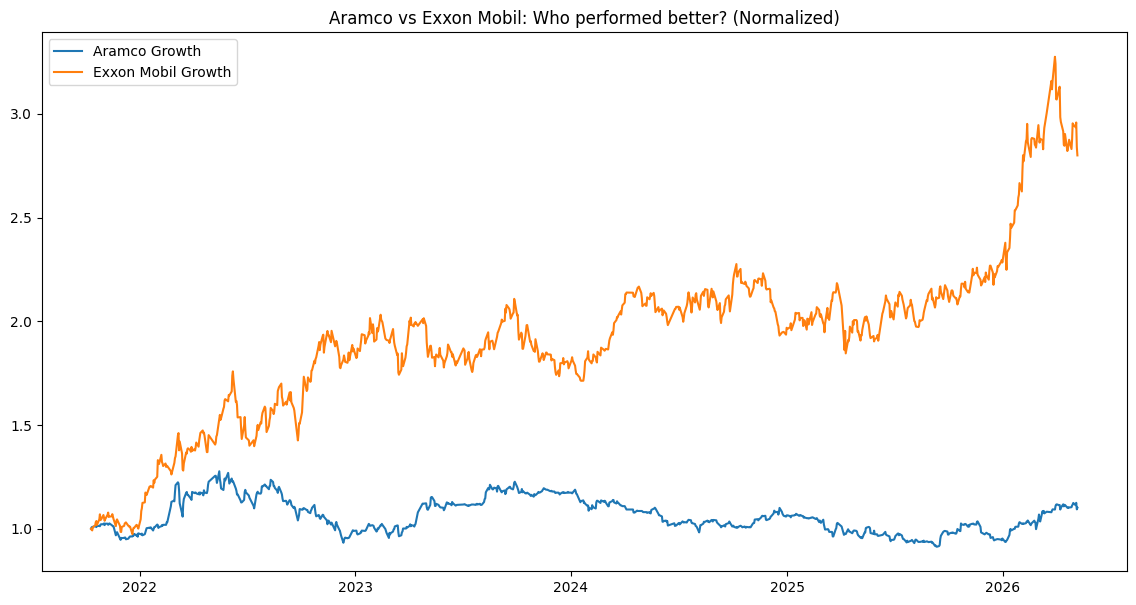

In [85]:
comparison_df['Aramco_Growth'] = (comparison_df['Aramco'] / comparison_df['Aramco'].iloc[0])
comparison_df['Exxon_Growth'] = (comparison_df['Exxon'] / comparison_df['Exxon'].iloc[0])

plt.figure(figsize=(14,7))
plt.plot(comparison_df['Aramco_Growth'], label='Aramco Growth')
plt.plot(comparison_df['Exxon_Growth'], label='Exxon Mobil Growth')
plt.title('Aramco vs Exxon Mobil: Who performed better? (Normalized)')
plt.legend()
plt.show()

In [86]:
growth_df = comparison_df / comparison_df.iloc[0]

In [87]:
growth_df.to_csv('Stocks_Growth_Comparison.csv')
print('File Saved Successfully')

File Saved Successfully


In [88]:
comparison_df.to_csv('Aramco_vs_Exxon_Analysis.csv')
print('File Saved Successfully')

File Saved Successfully
